# TKSA-MC Jupyter Tutorial

This notebook walks through a complete TKSA-MC run from a cloned repository. It is meant for people who want to run the example first, inspect the generated files, then change parameters or edit the Python code.

## What you will do

1. Locate the repository files from inside the notebook.
2. Optionally install TKSA-MC from the local clone.
3. Run TKSA-MC on the sample ubiquitin PDB file.
4. Read the output CSV and display the generated plot.
5. Run a small pH sweep.
6. Call the solver functions directly for code experiments.

In [1]:
from pathlib import Path
import os
import re
import subprocess
import sys

def find_repo_root(start=None):
    """Find the repository root by walking upward from the notebook location."""
    path = Path(start or os.getcwd()).resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "run_local.py").exists() and (candidate / "sample_pdb_1ubq.pdb").exists():
            return candidate
    raise FileNotFoundError("Could not find the TKSA-MC repository root.")

REPO_ROOT = find_repo_root()
SAMPLE_PDB = REPO_ROOT / "sample_pdb_1ubq.pdb"
OUTPUT_DIR = REPO_ROOT / "tutorial_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repository root: {REPO_ROOT}")
print(f"Sample PDB:       {SAMPLE_PDB}")
print(f"Output folder:    {OUTPUT_DIR}")

Repository root: C:\Projects\tksamc
Sample PDB:       C:\Projects\tksamc\sample_pdb_1ubq.pdb
Output folder:    C:\Projects\tksamc\tutorial_outputs


## Install dependencies

If you already installed the package and dependencies, leave `INSTALL_FROM_SOURCE = False`. If imports fail later, set it to `True` and run the cell again. The local install uses editable mode, so code changes in this clone are picked up without reinstalling.

In [2]:
INSTALL_FROM_SOURCE = False

if INSTALL_FROM_SOURCE:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", str(REPO_ROOT)])
else:
    print("Skipping install. Set INSTALL_FROM_SOURCE = True if imports are missing.")

Skipping install. Set INSTALL_FROM_SOURCE = True if imports are missing.


## Check imports

TKSA-MC needs `numpy`, `scipy`, `matplotlib`, `mdtraj`, and `numba`. The first Monte Carlo run can take longer because `numba` compiles the sampling function.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mdtraj as md
import numba

import tksamc

print("Imports are ready.")

Imports are ready.


## Run TKSA-MC on the sample PDB

This cell runs the same command shown in the README, but sends all generated files to `tutorial_outputs/` so the repository root stays tidy.

In [4]:
cmd = [
    sys.executable,
    str(REPO_ROOT / "run_local.py"),
    "-f", str(SAMPLE_PDB),
    "-ph", "7.0",
    "-T", "300.0",
    "-s", "MC",
    "-plot", "yes",
]

result = subprocess.run(cmd, cwd=OUTPUT_DIR, text=True, capture_output=True, check=True)
print(result.stdout)
if result.stderr:
    print(result.stderr)

################################################
ðŸ˜º ### TKSA started ### ðŸ˜º
Input file: C:\Projects\tksamc\sample_pdb_1ubq.pdb
pH  = 7.0
T   = 300.0
Elec. Energy Calc Method = TK
Statistical Method = MC
Plot = yes
Running SASA - MDTraj (Shrake-Rupley)
Using Header (Legacy/Richards) Reference Areas for Normalization.
There are: 25 Charged_residues
ðŸ˜º ### TKSA - MC ### ðŸ˜º
Ran in 2.350578 sec
Total dG Energy:  -42.43772302257222
ðŸ˜º ### Finished ### ðŸ˜º



## Inspect generated files

TKSA-MC writes a CSV with per-residue values and, when `-plot yes`, a JPG figure.

In [ ]:
import csv

csv_files = sorted(OUTPUT_DIR.glob("Output_MC_sample_pdb_1ubq_pH_7.0_T_300.0.csv"))
fig_files = sorted(OUTPUT_DIR.glob("Fig_MC_sample_pdb_1ubq_pH_7.0_T_300.0.jpg"))

if not csv_files:
    raise FileNotFoundError("Expected TKSA-MC output CSV was not created.")

csv_path = csv_files[-1]
fig_path = fig_files[-1] if fig_files else None

with csv_path.open() as handle:
    header = handle.readline().lstrip("# ").strip()
    columns = header.split(",")
    rows = list(csv.DictReader(handle, fieldnames=columns))

total_match = re.search(r"Total_dG=([-+0-9.eE]+)", header)
total_dg = float(total_match.group(1)) if total_match else None

print(f"CSV file: {csv_path}")
print(f"Rows:     {len(rows)}")
print(f"Total dG: {total_dg:.6f} kJ/mol" if total_dg is not None else "Total dG not found")

rows[:5]

In [ ]:
from IPython.display import Image, display

if fig_path is None:
    print("No figure was generated. Run with -plot yes to create one.")
else:
    print(fig_path)
    display(Image(filename=str(fig_path)))

## New exact vs MC plot functionality

The `tksamc` program can now generate two different microstate energy plots when you use `-plot yes`:

* `-s MC` creates the standard per-residue output plus `Fig_MC_..._sampling_dist.jpg`, which shows the sampled MC microstate energies.
* `-s EX` creates the exact solver output plus `Fig_EX_..._microstate_dist.jpg`, which shows the exact Boltzmann-weighted microstate energy distribution for small systems.

For the sample PDB, the exact plot is useful for validating the MC sampling behavior because it shows the full energy distribution of every protonation microstate.

### Running the program

Use the local `run_local.py` wrapper or the installed `tksamc` entry point. Examples:

```python
cmd = [sys.executable, str(REPO_ROOT / 'run_local.py'), '-f', str(SAMPLE_PDB), '-ph', '7.0', '-T', '300.0', '-s', 'MC', '-plot', 'yes']
cmd = [sys.executable, str(REPO_ROOT / 'run_local.py'), '-f', str(SAMPLE_PDB), '-ph', '7.0', '-T', '300.0', '-s', 'EX', '-plot', 'yes']
```

### Output files

The commands above produce:

* `Output_MC_sample_pdb_1ubq_pH_7.0_T_300.0.csv` and `Fig_MC_sample_pdb_1ubq_pH_7.0_T_300.0.jpg`
* `Fig_MC_sample_pdb_1ubq_pH_7.0_T_300.0_sampling_dist.jpg`
* `Fig_EX_sample_pdb_1ubq_pH_7.0_T_300.0_microstate_dist.jpg`

### Using the new plot helpers directly

You can also call the solver functions from Python for experiments. For example, to compare exact and MC microstate distributions in code, import `tksamc.solver` and use `solve_exact(..., return_microstate_energies=True)` and `solve_mc(...)`.

## Run a small pH sweep

This loop changes one command-line parameter at a time. For repeated runs, `-plot no` is useful because it avoids creating many image files.

In [ ]:
def run_tksamc(ph, temperature=300.0, solver="MC", plot="no"):
    cmd = [
        sys.executable,
        str(REPO_ROOT / "run_local.py"),
        "-f", str(SAMPLE_PDB),
        "-ph", str(ph),
        "-T", str(temperature),
        "-s", solver,
        "-plot", plot,
    ]
    subprocess.run(cmd, cwd=OUTPUT_DIR, text=True, capture_output=True, check=True)
    output_csv = OUTPUT_DIR / f"Output_{solver}_sample_pdb_1ubq_pH_{float(ph)}_T_{float(temperature)}.csv"
    with output_csv.open() as handle:
        header = handle.readline().strip()
    match = re.search(r"Total_dG=([-+0-9.eE]+)", header)
    return float(match.group(1)) if match else np.nan

sweep = []
for ph in [5.0, 7.0, 9.0]:
    sweep.append({"pH": ph, "total_dG_kJ_mol": run_tksamc(ph)})

sweep

In [ ]:
ph_values = [item["pH"] for item in sweep]
dg_values = [item["total_dG_kJ_mol"] for item in sweep]

plt.figure(figsize=(5, 3))
plt.plot(ph_values, dg_values, marker="o")
plt.xlabel("pH")
plt.ylabel("Total dG (kJ/mol)")
plt.title("TKSA-MC pH sweep")
plt.grid(alpha=0.3)
plt.show()

## Call solver functions directly

For code experiments, you can import `tksamc.solver` directly. The toy system below is intentionally small, so exact enumeration is safe.

Exact per-residue dG: [-0.39885442 -0.09980897  0.09929542]
MC per-residue dG:    [-3.98076088e-04 -9.95522800e-05  9.91531840e-05]
<module 'matplotlib.pyplot' from 'c:\\Users\\tomas\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\matplotlib\\pyplot.py'>


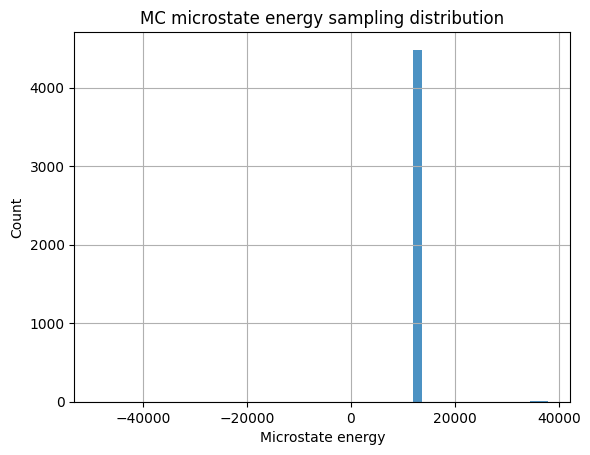

In [ ]:
from tksamc import solver as tksamc_solver

Eij = np.array([
    [0.0, 1.2, 0.4],
    [1.2, 0.0, 0.8],
    [0.4, 0.8, 0.0],
], dtype=float)
charges = np.array([0.0, -1.0, -1.0], dtype=float)
pkas = np.array([10.6, 4.5, 4.0], dtype=float)
ph = 7.0
temperature = 300.0

exact_gqq = tksamc_solver.solve_exact(Eij, charges, pkas, ph, temperature)
mc_gqq, sampling_dist = tksamc_solver.solve_mc(Eij, charges, pkas, ph, temperature, steps=5000, equil_steps=500)

print("Exact per-residue dG:", exact_gqq)
print("MC per-residue dG:   ", mc_gqq)

## Editing code while the notebook is open

If you modify files under `tksamc/`, enable autoreload so the notebook picks up changes when you re-run cells. After changing core solver code, re-run the import and the cells that depend on it.

In [3]:
%load_ext autoreload
%autoreload 2

## Troubleshooting

- `ModuleNotFoundError`: set `INSTALL_FROM_SOURCE = True` near the top and re-run the install cell.
- `mdtraj` install problems: create a fresh environment, then install dependencies with `python -m pip install numpy scipy matplotlib mdtraj numba notebook`.
- Slow first MC run: this is usually `numba` compiling the Monte Carlo function. Later runs should be faster.
- Too many output files: use `-plot no` for sweeps, or delete files in `tutorial_outputs/`.
- Exact solver is slow on large proteins: use `-s MC` for normal protein-size runs. Exact enumeration scales as 2^N with the number of ionizable residues.

## Comparing Monte Carlo (MC) vs Exact (EX) sampling

This new section demonstrates the `compare_exact_mc` helper and the CLI `-compare` flag. The comparison computes per-residue ΔG using the exact enumeration method and using Monte Carlo sampling, then reports per-residue differences and summary statistics (RMSE, mean difference, max absolute difference). Use this to evaluate how many MC steps are necessary for the Monte Carlo sampling to approximate the exact solution for average energy per residue.

Key points:
- The function `compare_exact_mc(E, Q, Pk, pH, T, mc_steps=..., mc_equil=...)` returns a dictionary with keys: `ex_vals_kj`, `mc_vals_kj`, `diffs`, `rmse`, `mean_diff`, `max_abs_diff`, `sampling_dist`, `exact_energies`, `exact_weights`.
- The helper `plot_compare_residues(ex_vals_kj, mc_vals_kj)` creates a bar chart (Exact vs MC per residue) and a histogram of per-residue errors.
- The CLI flag `-compare yes` runs the exact solver and MC solver, saves `Fig_COMPARE_...jpg` and `Output_COMPARE_...csv` alongside the regular outputs.

Warnings and guidance:
- Exact enumeration grows exponentially with the number of ionizable residues: use it only for small proteins or short residue sets.
- If the RMSE is large, increase `mc_steps` (and `mc_equil`) until the MC results converge toward Exact. Typical starting values: `mc_steps=50000`, `mc_equil=5000`.

Example usage (Python API):

```python
# Assumes E, Q, Pk, pH, T are defined earlier in this notebook by the TKSA workflow.
from tksamc import solver
comp = solver.compare_exact_mc(E, Q, Pk, pH=7.0, T=300.0, mc_steps=50000, mc_equil=5000)
print('RMSE (kJ/mol):', comp['rmse'])

import matplotlib.pyplot as plt
solver.plot_compare_residues(comp['ex_vals_kj'], comp['mc_vals_kj'])
plt.show()
```

CLI example:

```bash
python run_local.py -f sample_1BTA.pdb -ph 7.0 -T 300.0 -s MC -compare yes
```

When run via the CLI with `-compare yes`, the existing outputs remain unchanged and the additional comparison files are created separately.


In [ ]:
# Example: run the comparison helper on the current problem setup
# (This cell assumes `E`, `Q`, `Pk`, `pH`, `T` are already defined earlier in the notebook.)
from tksamc import solver
import matplotlib.pyplot as plt

# Run comparison with fewer MC steps for a quick demo; increase for production
comp = solver.compare_exact_mc(E, Q, Pk, pH, T, mc_steps=5000, mc_equil=500)
print(f"RMSE (kJ/mol): {comp['rmse']:.6f}")
print(f"Mean difference (kJ/mol): {comp['mean_diff']:.6f}")
print(f"Max abs difference (kJ/mol): {comp['max_abs_diff']:.6f}")

# Plot comparison
solver.plot_compare_residues(comp['ex_vals_kj'], comp['mc_vals_kj'])
plt.show()
